In [94]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np  
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

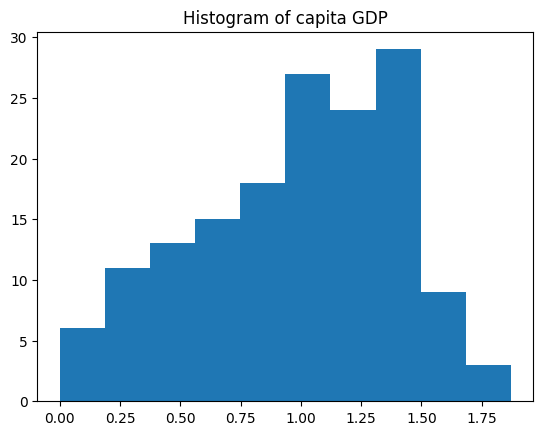

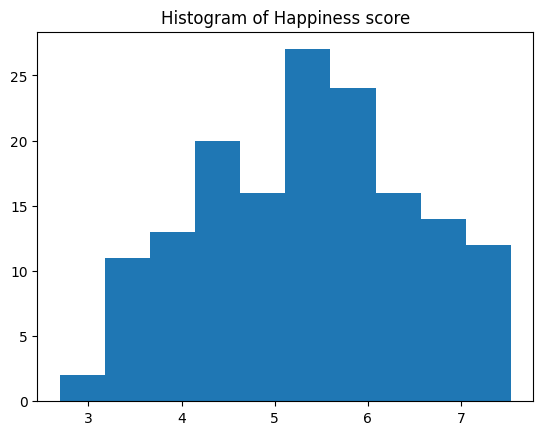

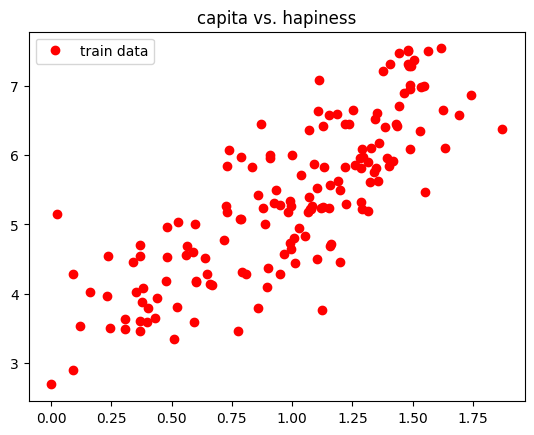

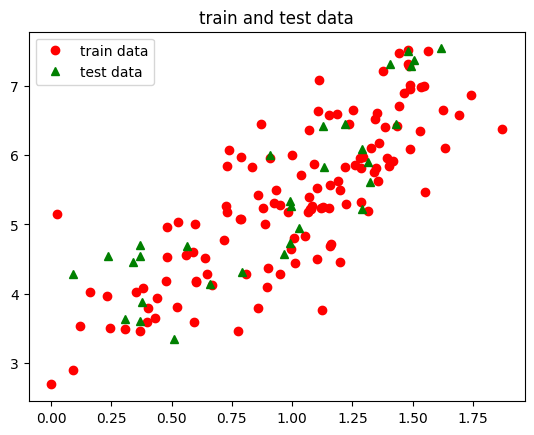

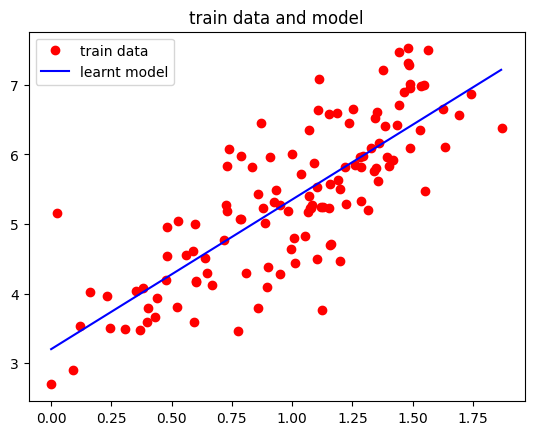

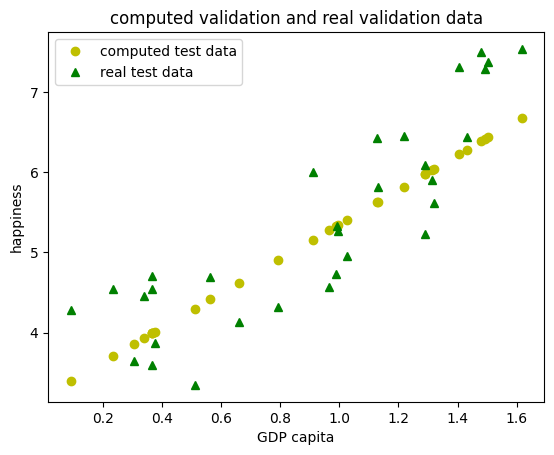

mse (manual):  0.4142120438505252
mse (tool):  0.41421204385052524
R^2 score (manual): 0.7218126270099263
R^2 score:  0.7218126270099262


In [95]:
# Produsul intern brut (v1)
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) if data[i][selectedVariable] != '' else 0.0 for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) if data[i][selectedOutput] != '' else 0.0 for i in range(len(data))]
    return inputs, outputs

def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

def plotData(x1, y1, x2 = None, y2 = None, x3 = None, y3 = None, title = None):
    plt.plot(x1, y1, 'ro', label = 'train data')
    if (x2):
        plt.plot(x2, y2, 'b-', label = 'learnt model')
    if (x3):
        plt.plot(x3, y3, 'g^', label = 'test data')
    plt.title(title)
    plt.legend()
    plt.show()

crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

plotDataHistogram(inputs, 'capita GDP')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

xx = [[el] for el in trainInputs]
regressor = linear_model.LinearRegression()
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

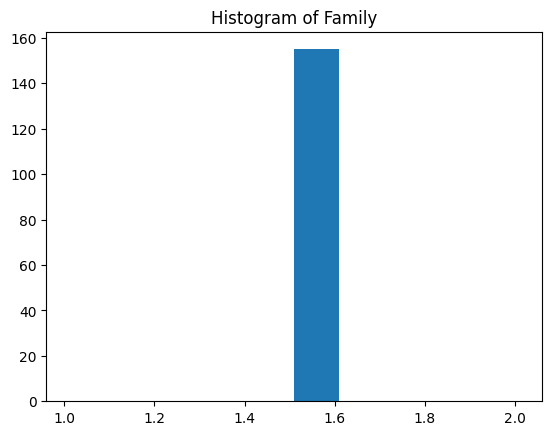

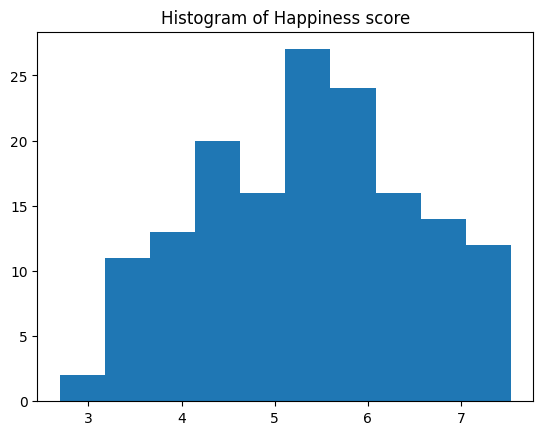

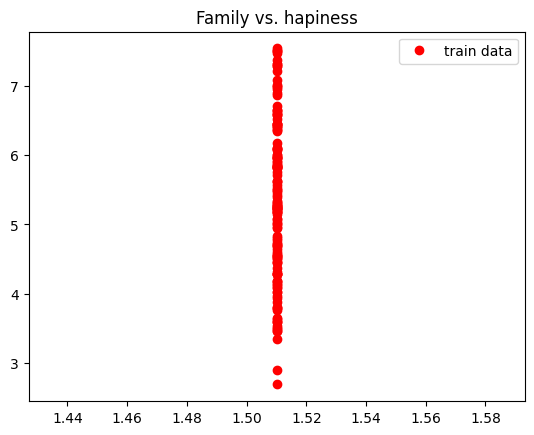

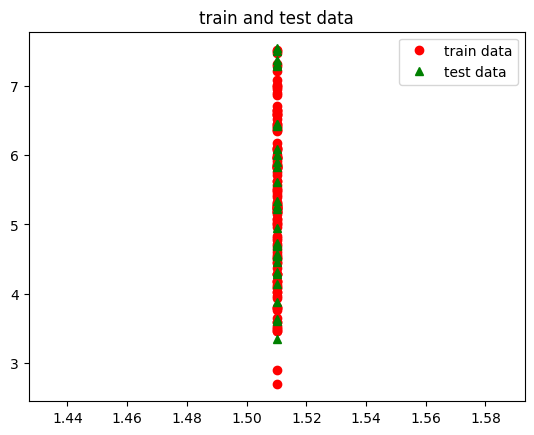

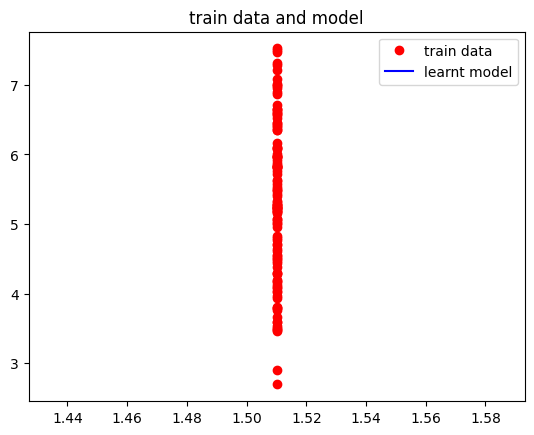

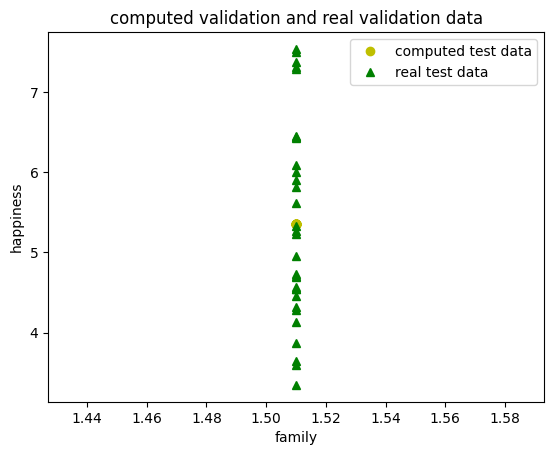

mse (manual):  1.488969965516146
mse (tool):  1.488969965516146
R^2 score (manual): -1.4468858182681288e-06
R^2 score:  -1.4468858184901734e-06


In [96]:
# Family (v1)
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Family', 'Happiness.Score')

plotDataHistogram(inputs, 'Family')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'Family vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

xx = [[el] for el in trainInputs]
regressor = linear_model.LinearRegression()
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

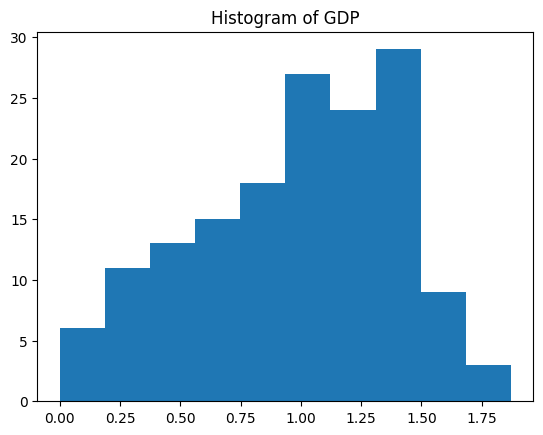

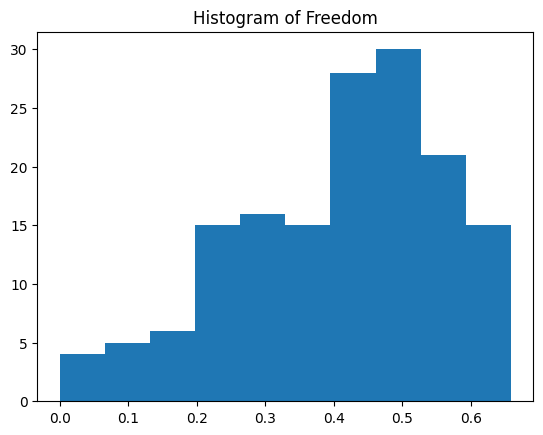

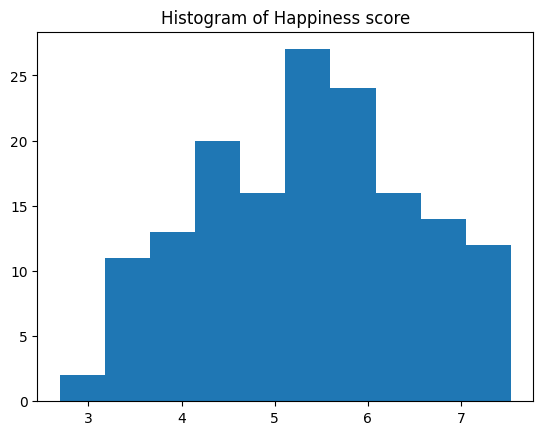

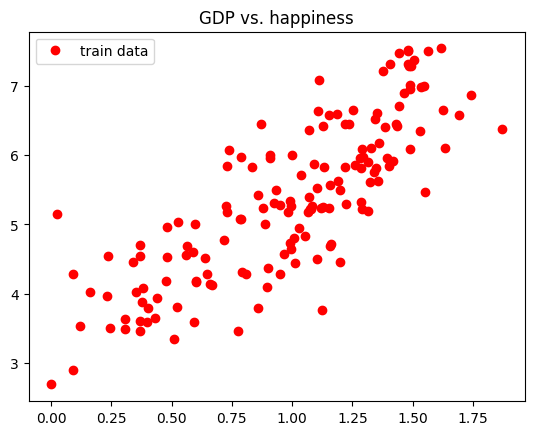

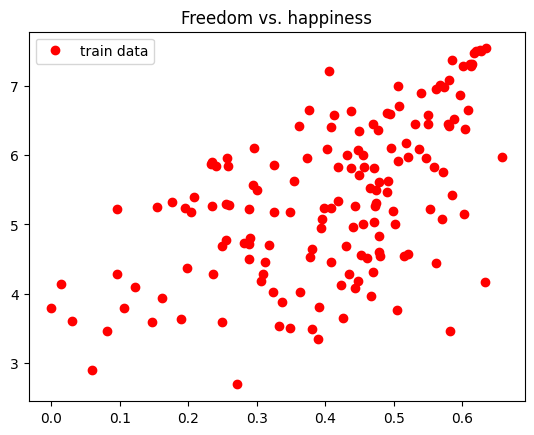

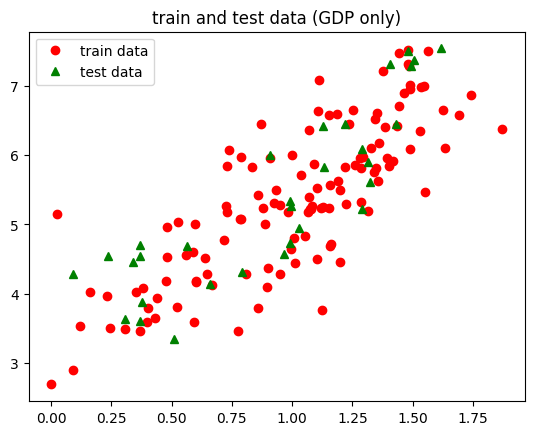

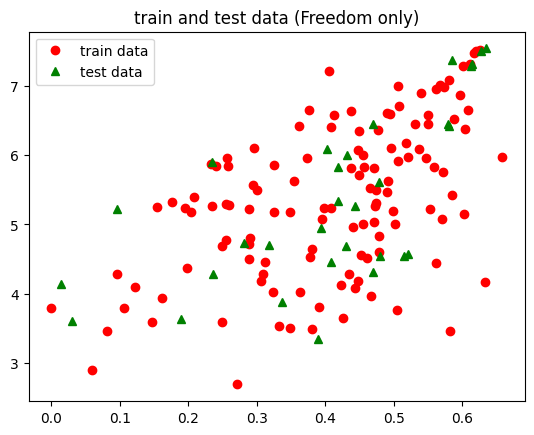

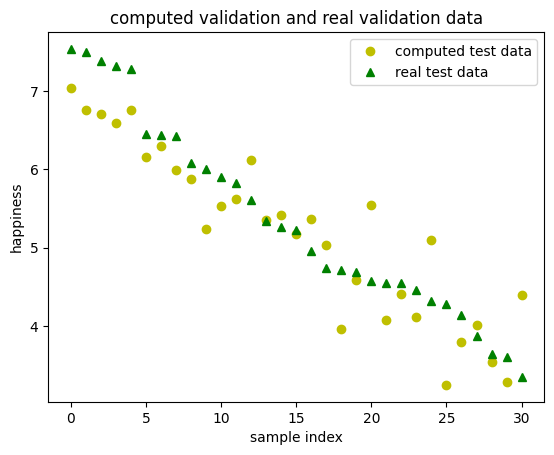

mse (manual): 0.2778267436200108
mse (tool): 0.2778267436200108
R^2 score (manual): 0.813409838990756
R^2 score: 0.813409838990756


In [97]:
# GDP + Freedom (v1)
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs_gdp, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
inputs_freedom, _ = loadData(filePath, 'Freedom', 'Happiness.Score')

plotDataHistogram(inputs_gdp, 'GDP')
plotDataHistogram(inputs_freedom, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs_gdp, outputs, [], [], [], [], 'GDP vs. happiness')
plotData(inputs_freedom, outputs, [], [], [], [], 'Freedom vs. happiness')

X = [[gdp, freedom] for gdp, freedom in zip(inputs_gdp, inputs_freedom)]

np.random.seed(5)
indexes = [i for i in range(len(X))]
trainSample = np.random.choice(indexes, int(0.8 * len(X)), replace=False)
validationSample = [i for i in indexes if not i in trainSample]

trainInputs = [X[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [X[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

train_gdp = [inputs_gdp[i] for i in trainSample]
validation_gdp = [inputs_gdp[i] for i in validationSample]
plotData(train_gdp, trainOutputs, [], [], validation_gdp, validationOutputs, "train and test data (GDP only)")

train_freedom = [inputs_freedom[i] for i in trainSample]
validation_freedom = [inputs_freedom[i] for i in validationSample]
plotData(train_freedom, trainOutputs, [], [], validation_freedom, validationOutputs, "train and test data (Freedom only)")

regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]

computedValidationOutputs = regressor.predict(validationInputs)

plt.plot(range(len(validationOutputs)), computedValidationOutputs, 'yo', label='computed test data')
plt.plot(range(len(validationOutputs)), validationOutputs, 'g^', label='real test data')
plt.title('computed validation and real validation data')
plt.xlabel('sample index')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual):", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool):", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score:", r2)

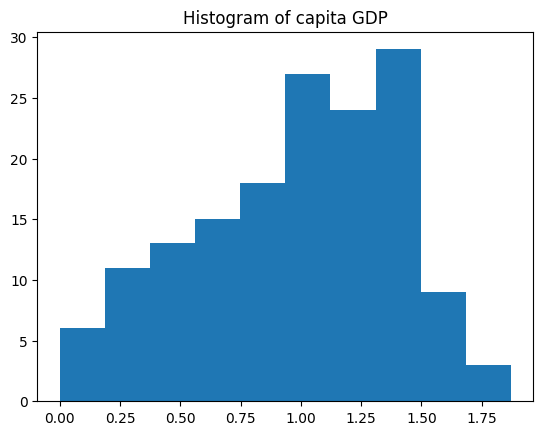

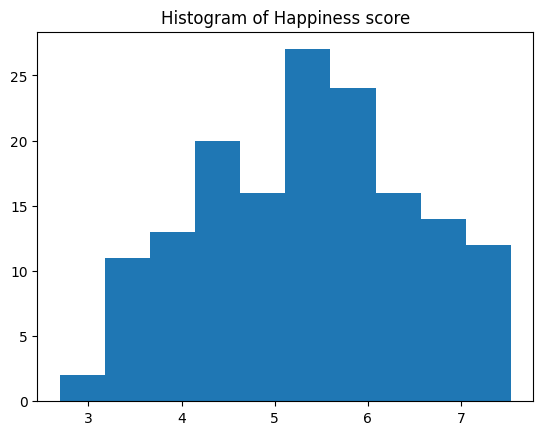

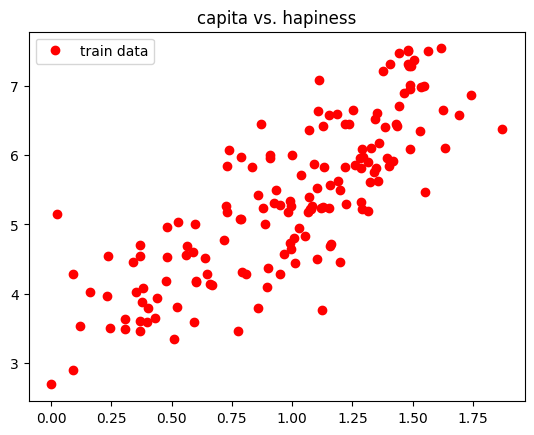

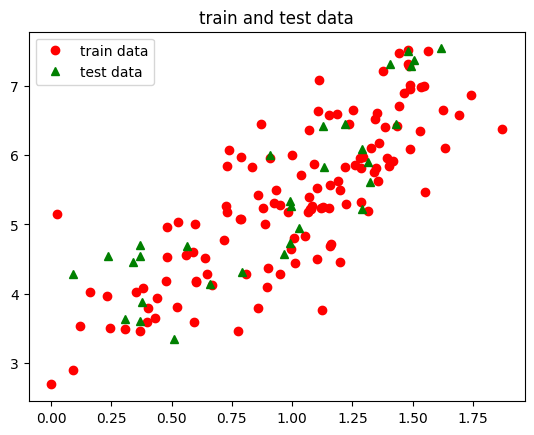

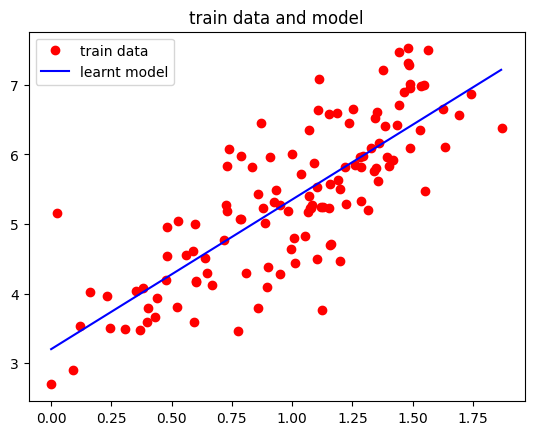

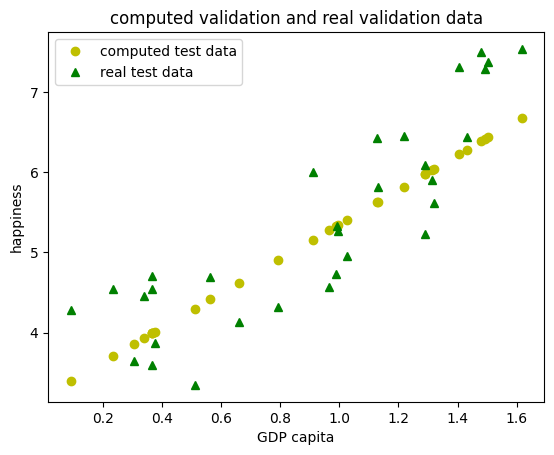

mse (manual):  0.4142120438505252
mse (tool):  0.41421204385052524
R^2 score (manual): 0.7218126270099263
R^2 score:  0.7218126270099262


In [98]:

# Produsul intern brut (v2)
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v2_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

plotDataHistogram(inputs, 'capita GDP')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

xx = [[el] for el in trainInputs]
regressor = linear_model.LinearRegression()
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

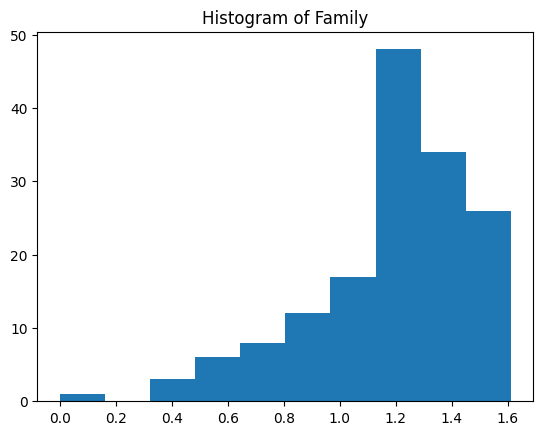

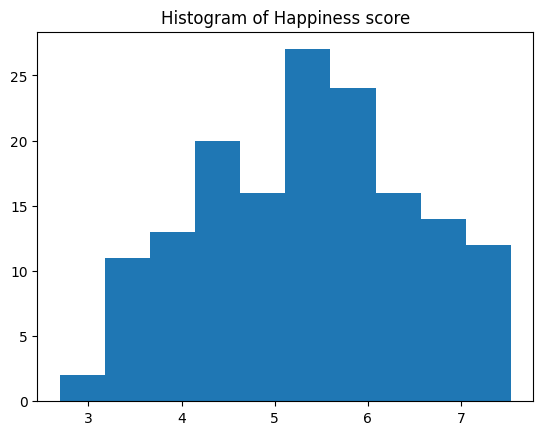

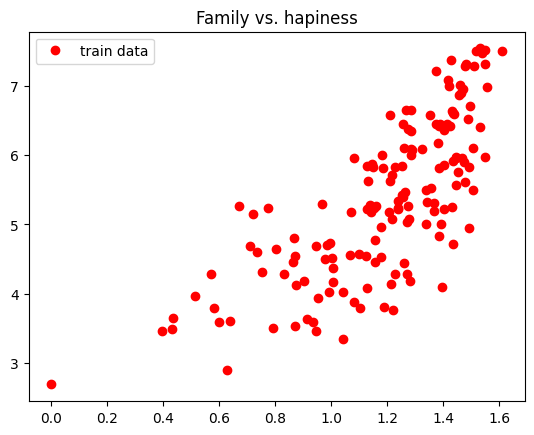

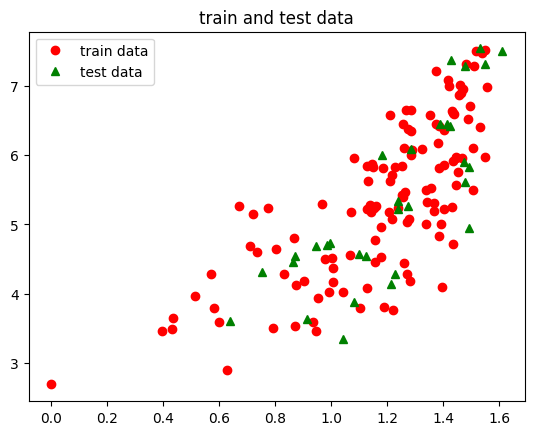

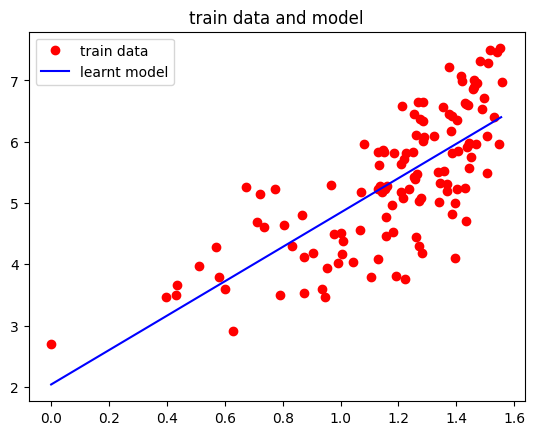

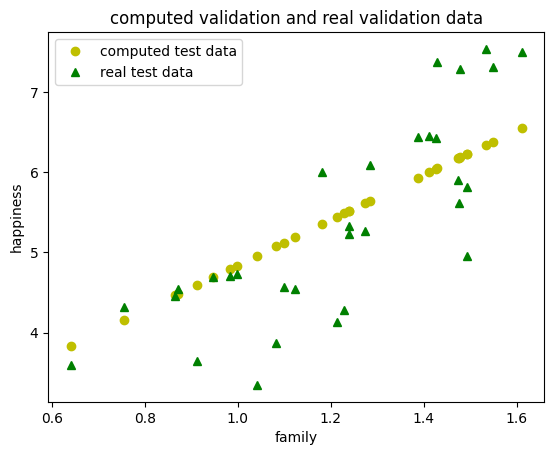

mse (manual):  0.6051231125473607
mse (tool):  0.6051231125473606
R^2 score (manual): 0.5935955713642305
R^2 score:  0.5935955713642305


In [99]:
# Family (v2)
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v2_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Family', 'Happiness.Score')

plotDataHistogram(inputs, 'Family')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'Family vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

xx = [[el] for el in trainInputs]
regressor = linear_model.LinearRegression()
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

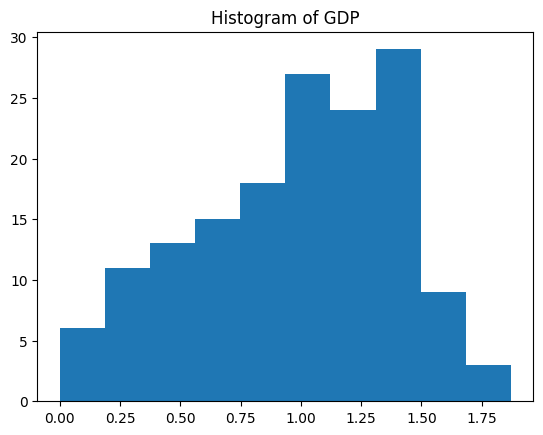

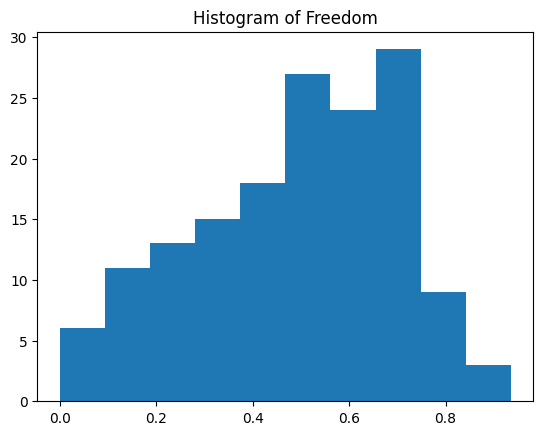

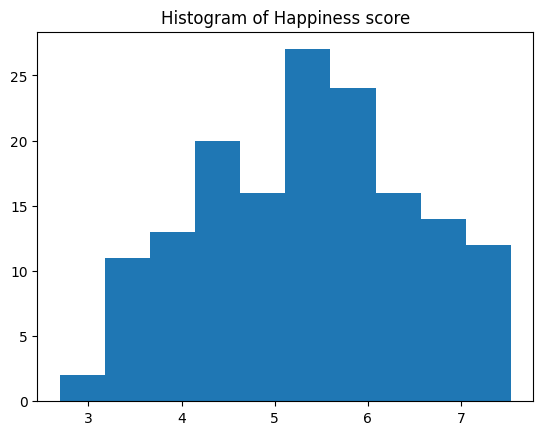

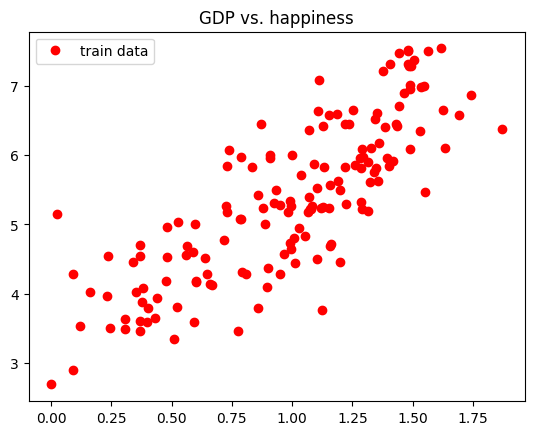

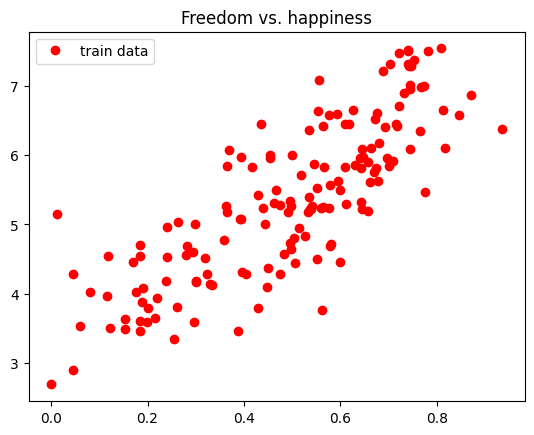

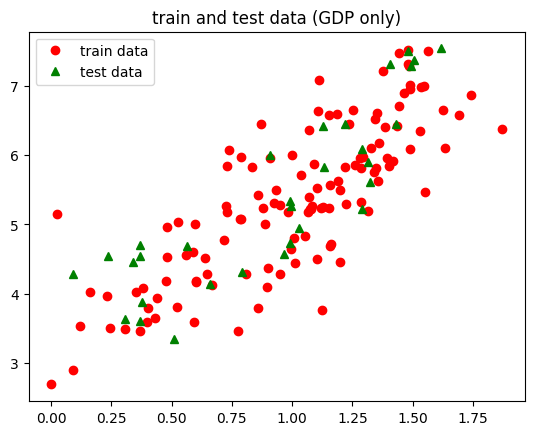

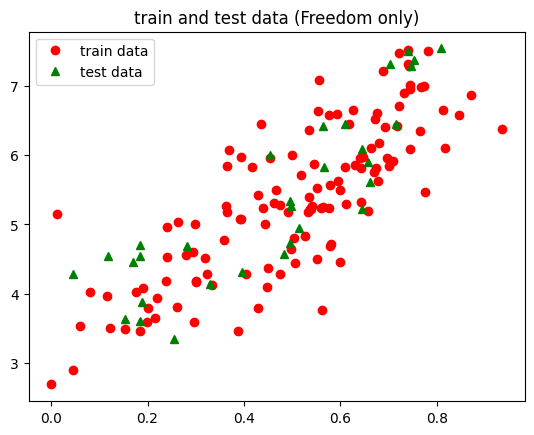

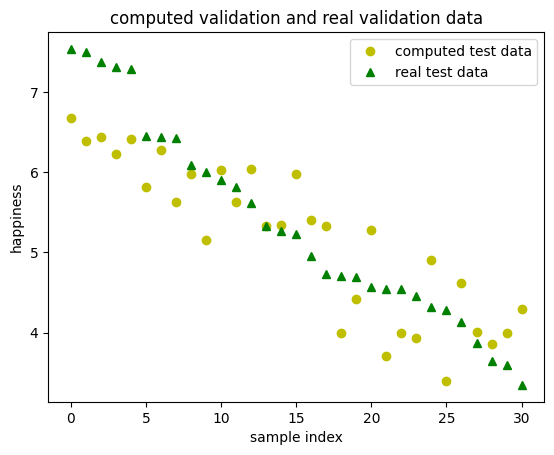

mse (manual): 0.41421024295199377
mse (tool): 0.4142102429519938
R^2 score (manual): 0.7218138365045292
R^2 score: 0.721813836504529


In [100]:
# GDP + Freedom (v2)
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v2_world-happiness-report-2017.csv')

inputs_gdp, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
inputs_freedom, _ = loadData(filePath, 'Freedom', 'Happiness.Score')

plotDataHistogram(inputs_gdp, 'GDP')
plotDataHistogram(inputs_freedom, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs_gdp, outputs, [], [], [], [], 'GDP vs. happiness')
plotData(inputs_freedom, outputs, [], [], [], [], 'Freedom vs. happiness')

X = [[gdp, freedom] for gdp, freedom in zip(inputs_gdp, inputs_freedom)]

np.random.seed(5)
indexes = [i for i in range(len(X))]
trainSample = np.random.choice(indexes, int(0.8 * len(X)), replace=False)
validationSample = [i for i in indexes if not i in trainSample]

trainInputs = [X[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [X[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

train_gdp = [inputs_gdp[i] for i in trainSample]
validation_gdp = [inputs_gdp[i] for i in validationSample]
plotData(train_gdp, trainOutputs, [], [], validation_gdp, validationOutputs, "train and test data (GDP only)")

train_freedom = [inputs_freedom[i] for i in trainSample]
validation_freedom = [inputs_freedom[i] for i in validationSample]
plotData(train_freedom, trainOutputs, [], [], validation_freedom, validationOutputs, "train and test data (Freedom only)")

regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]

computedValidationOutputs = regressor.predict(validationInputs)

plt.plot(range(len(validationOutputs)), computedValidationOutputs, 'yo', label='computed test data')
plt.plot(range(len(validationOutputs)), validationOutputs, 'g^', label='real test data')
plt.title('computed validation and real validation data')
plt.xlabel('sample index')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual):", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool):", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score:", r2)

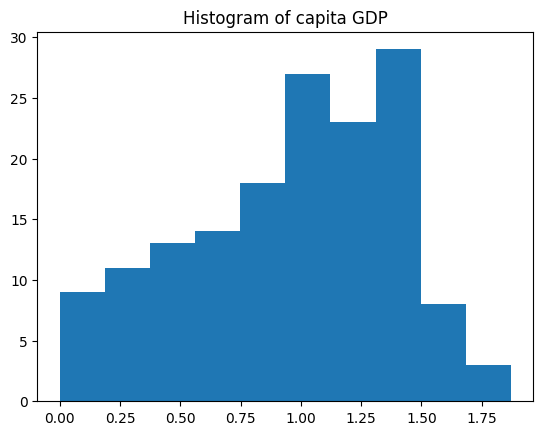

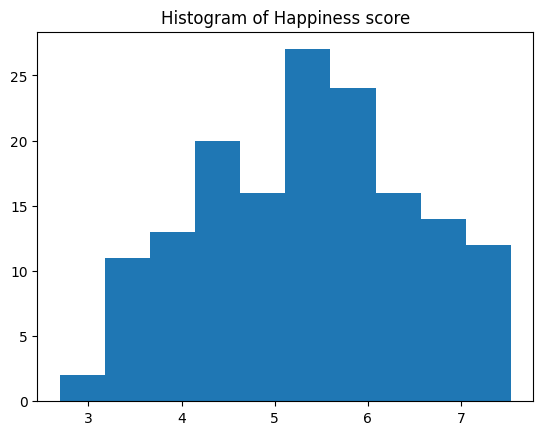

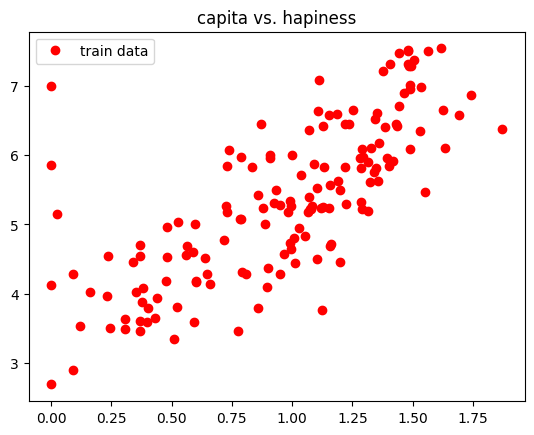

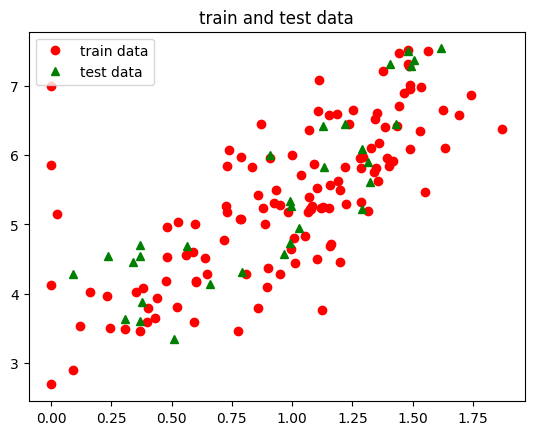

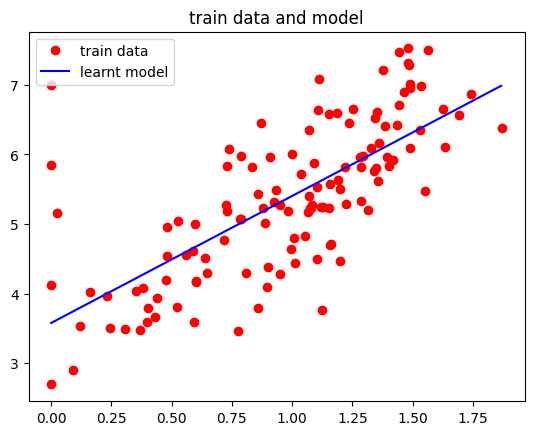

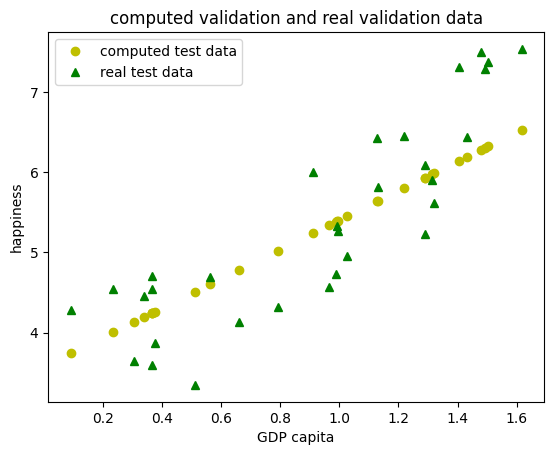

mse (manual):  0.4405777072388753
mse (tool):  0.44057770723887535
R^2 score (manual): 0.704105284251461
R^2 score:  0.704105284251461


In [101]:
# Produsul intern brut (v3)
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v3_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

plotDataHistogram(inputs, 'capita GDP')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

xx = [[el] for el in trainInputs]
regressor = linear_model.LinearRegression()
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

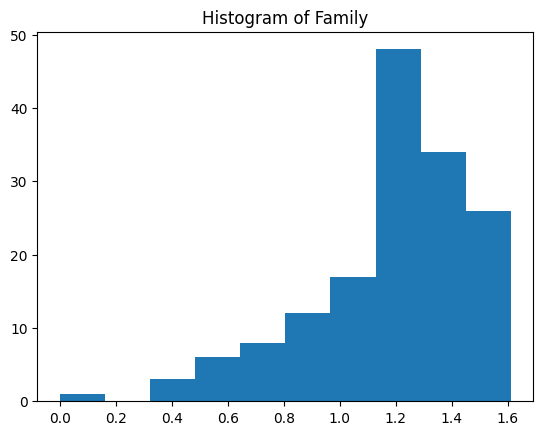

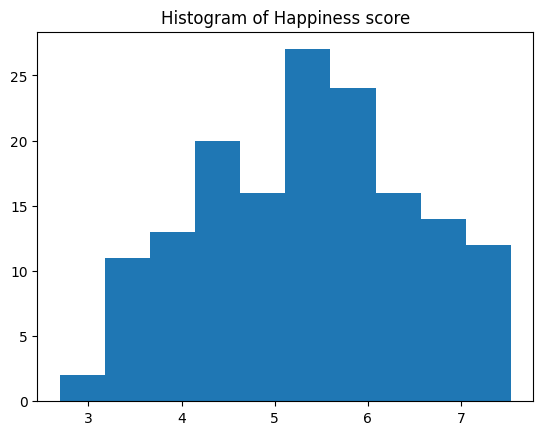

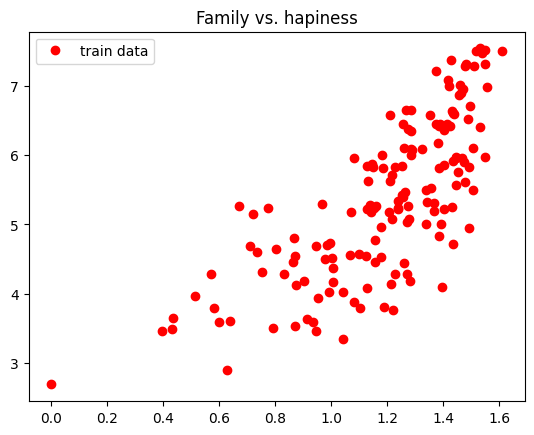

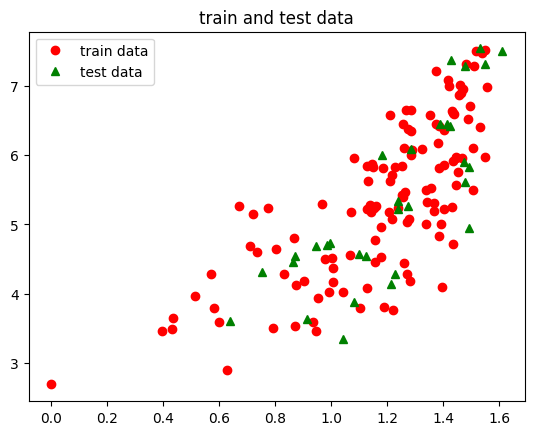

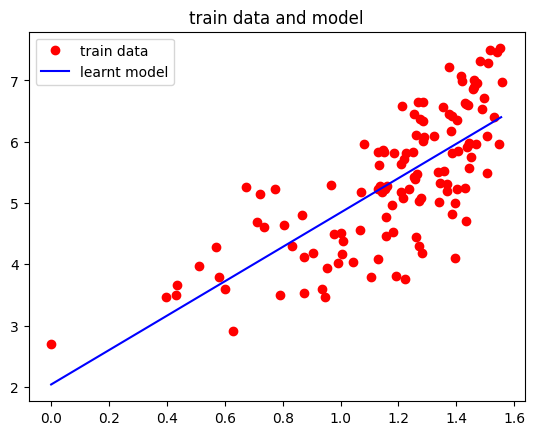

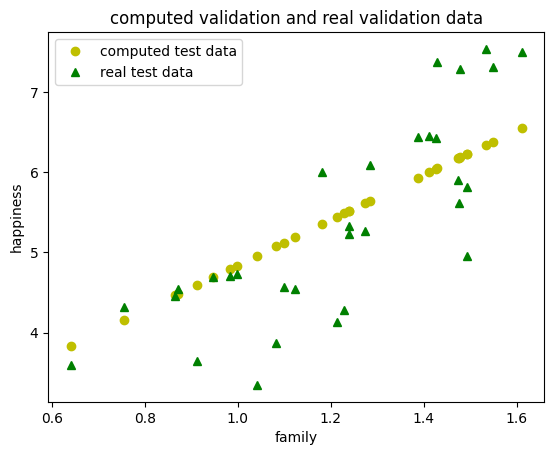

mse (manual):  0.6051231125473607
mse (tool):  0.6051231125473606
R^2 score (manual): 0.5935955713642305
R^2 score:  0.5935955713642305


In [102]:
# Family (v3)
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v3_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Family', 'Happiness.Score')

plotDataHistogram(inputs, 'Family')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'Family vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

xx = [[el] for el in trainInputs]
regressor = linear_model.LinearRegression()
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

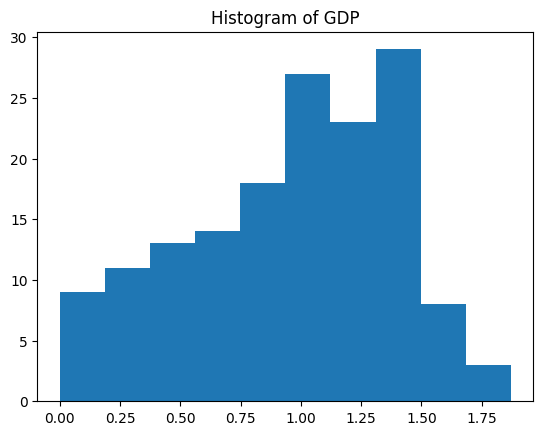

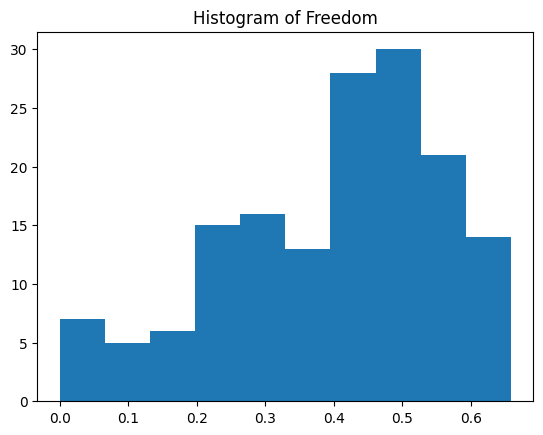

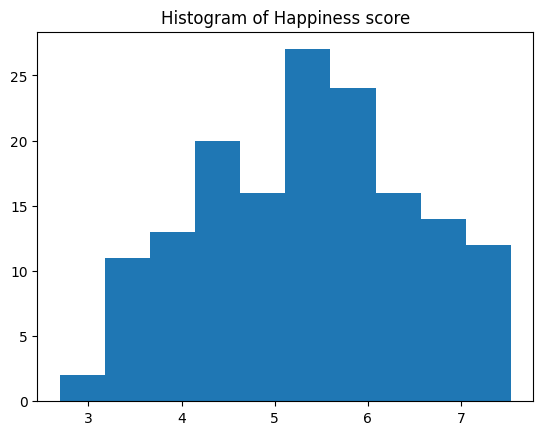

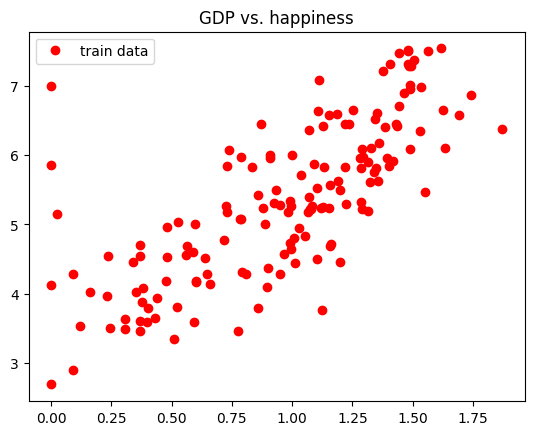

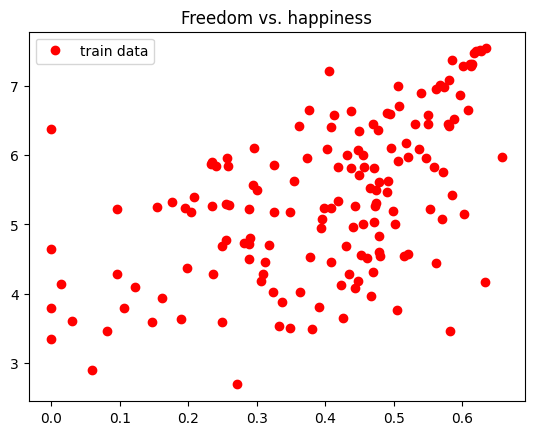

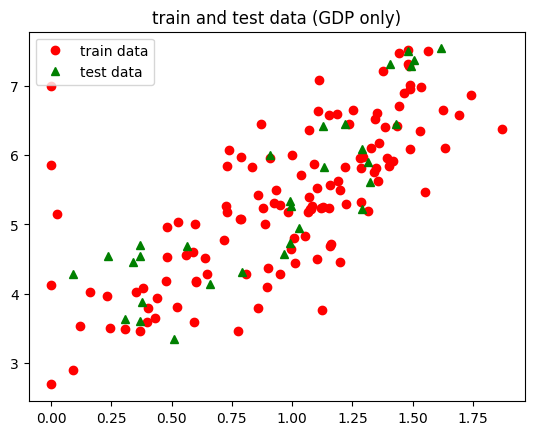

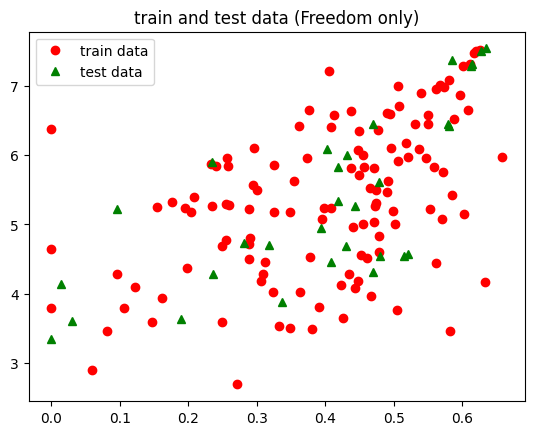

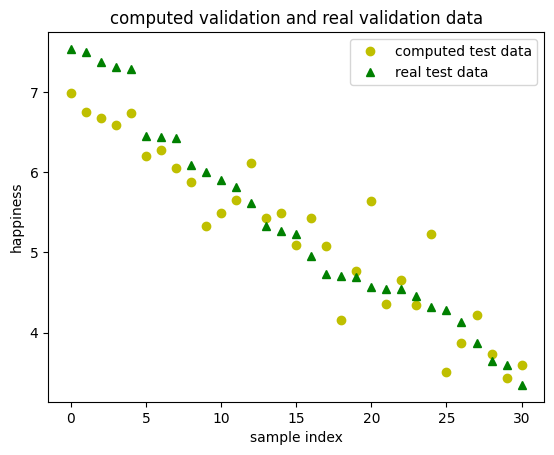

mse (manual): 0.2261590260231617
mse (tool): 0.22615902602316168
R^2 score (manual): 0.848110197997814
R^2 score: 0.848110197997814


In [103]:
# GDP + Freedom (v3)
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v3_world-happiness-report-2017.csv')

inputs_gdp, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
inputs_freedom, _ = loadData(filePath, 'Freedom', 'Happiness.Score')

plotDataHistogram(inputs_gdp, 'GDP')
plotDataHistogram(inputs_freedom, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs_gdp, outputs, [], [], [], [], 'GDP vs. happiness')
plotData(inputs_freedom, outputs, [], [], [], [], 'Freedom vs. happiness')

X = [[gdp, freedom] for gdp, freedom in zip(inputs_gdp, inputs_freedom)]

np.random.seed(5)
indexes = [i for i in range(len(X))]
trainSample = np.random.choice(indexes, int(0.8 * len(X)), replace=False)
validationSample = [i for i in indexes if not i in trainSample]

trainInputs = [X[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [X[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

train_gdp = [inputs_gdp[i] for i in trainSample]
validation_gdp = [inputs_gdp[i] for i in validationSample]
plotData(train_gdp, trainOutputs, [], [], validation_gdp, validationOutputs, "train and test data (GDP only)")

train_freedom = [inputs_freedom[i] for i in trainSample]
validation_freedom = [inputs_freedom[i] for i in validationSample]
plotData(train_freedom, trainOutputs, [], [], validation_freedom, validationOutputs, "train and test data (Freedom only)")

regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]

computedValidationOutputs = regressor.predict(validationInputs)

plt.plot(range(len(validationOutputs)), computedValidationOutputs, 'yo', label='computed test data')
plt.plot(range(len(validationOutputs)), validationOutputs, 'g^', label='real test data')
plt.title('computed validation and real validation data')
plt.xlabel('sample index')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual):", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool):", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score:", r2)

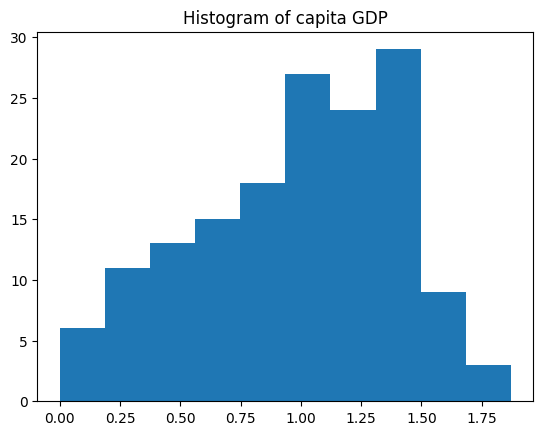

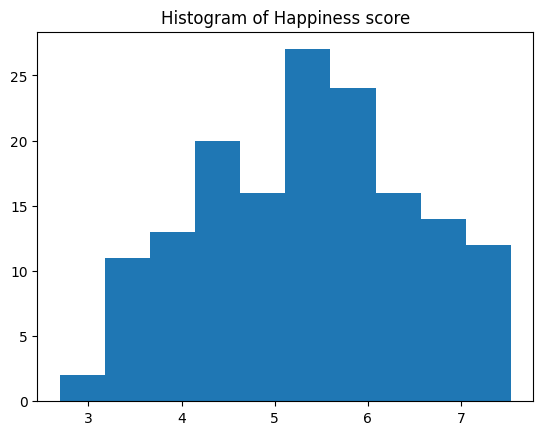

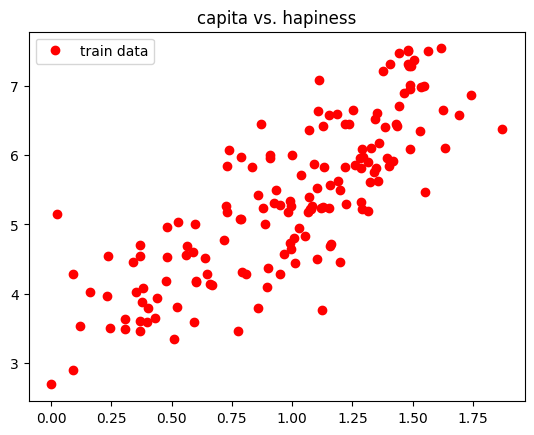

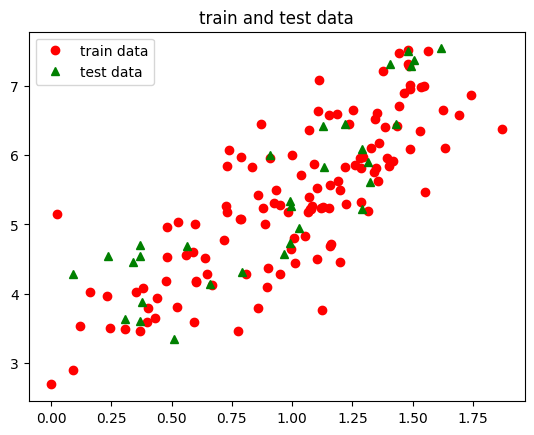

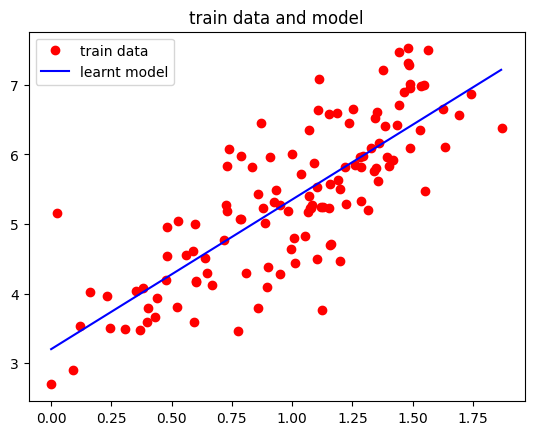

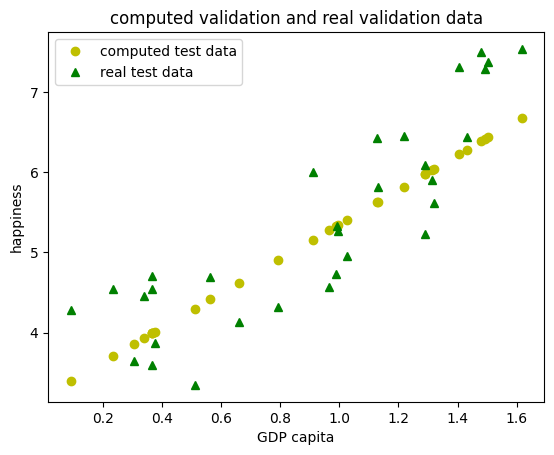

mse (manual):  0.4142120438505258
mse (tool):  0.41421204385052574
R^2 score (manual): 0.721812627009926
R^2 score:  0.7218126270099259


In [104]:
class MyLinearUnivariateRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = 0.0

    def fit(self, x, y):
        sx = sum(x)
        sy = sum(y)
        sx2 = sum(i * i for i in x)
        sxy = sum(i * j for (i,j) in zip(x, y))
        w1 = (len(x) * sxy - sx * sy) / (len(x) * sx2 - sx * sx)
        w0 = (sy - w1 * sx) / len(x)
        self.intercept_, self.coef_ =  w0, w1

    def predict(self, x):
        if (isinstance(x[0], list)):
            return [self.intercept_ + self.coef_ * val[0] for val in x]
        else:
            return [self.intercept_ + self.coef_ * val for val in x]
        
# Produsul intern brut (v1) custom
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

plotDataHistogram(inputs, 'capita GDP')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

regressor = MyLinearUnivariateRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

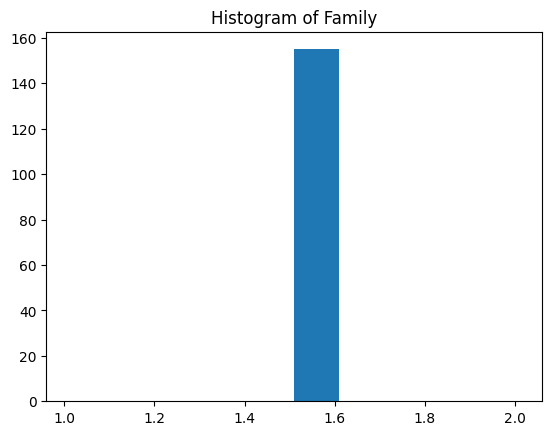

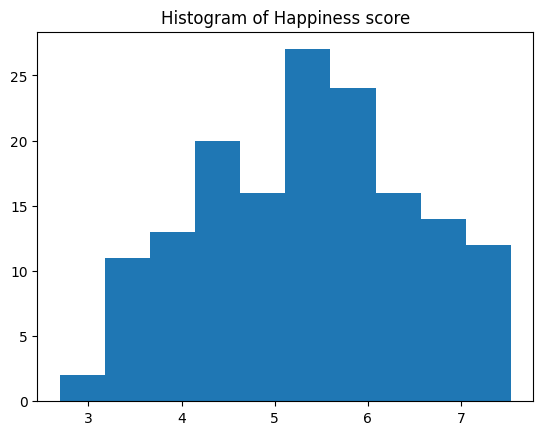

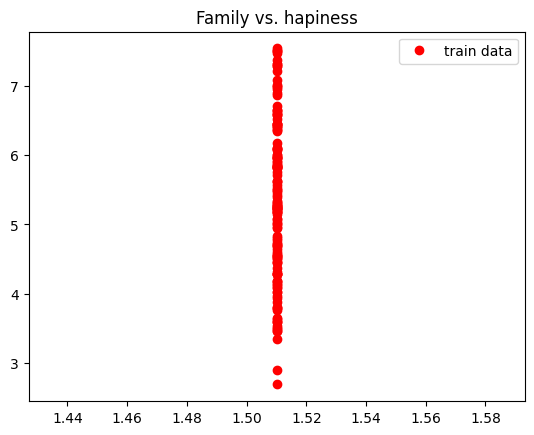

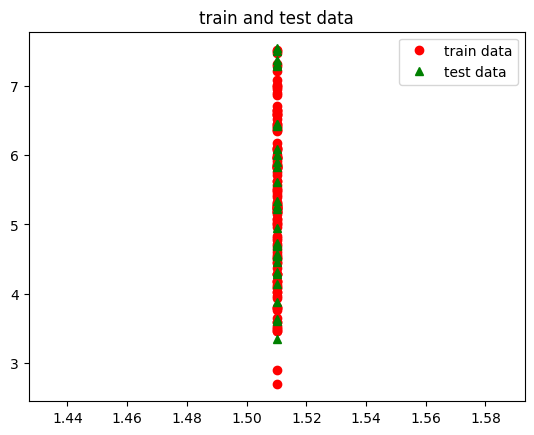

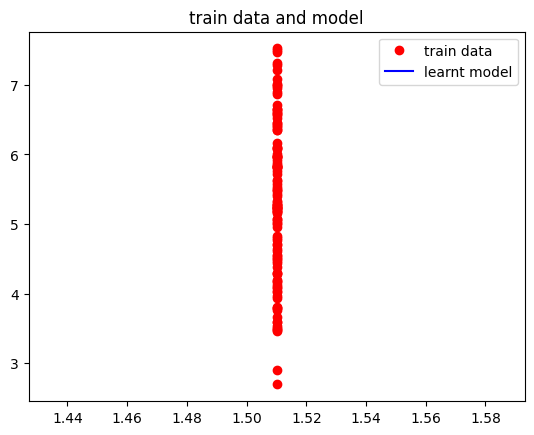

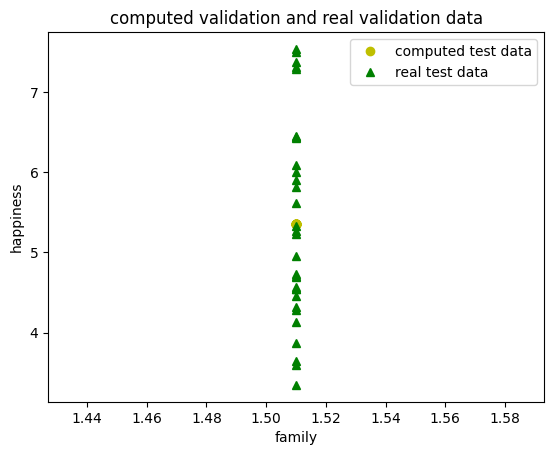

mse (manual):  1.488969965516146
mse (tool):  1.488969965516146
R^2 score (manual): -1.4468858182681288e-06
R^2 score:  -1.4468858184901734e-06


In [105]:
# Family (v1) custom
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Family', 'Happiness.Score')

plotDataHistogram(inputs, 'Family')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs, outputs, [], [], [], [], 'Family vs. hapiness')

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

regressor = MyLinearUnivariateRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref] 
plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data') 
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data') 
plt.title('computed validation and real validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual): ", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool): ", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score: ", r2)

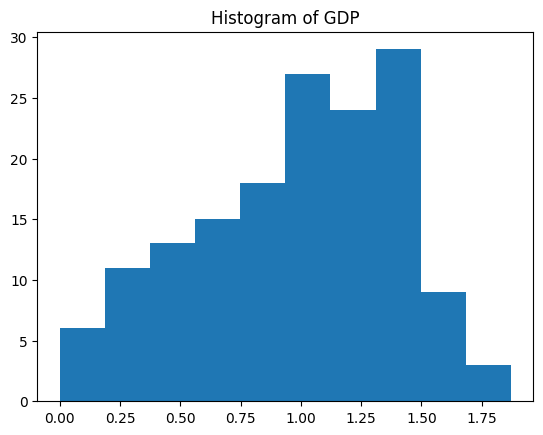

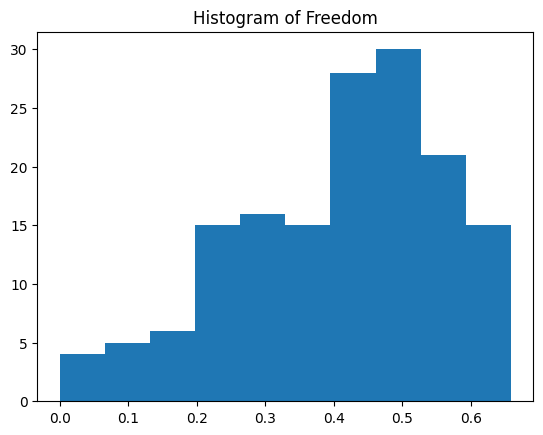

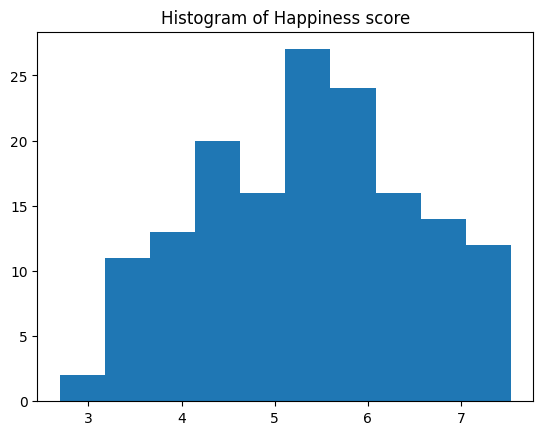

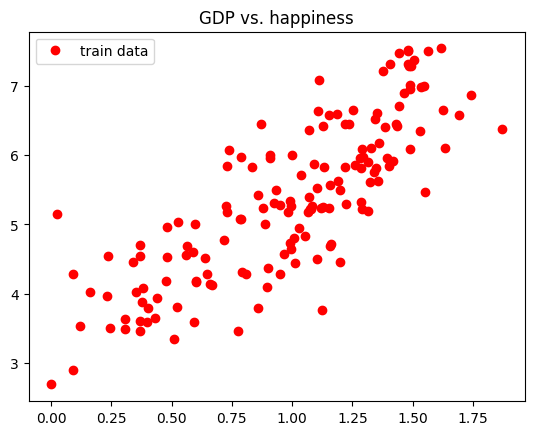

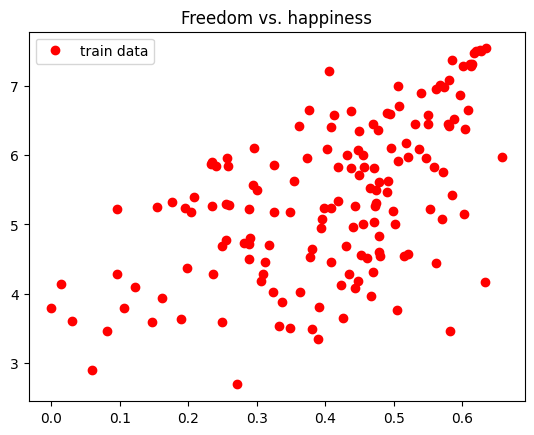

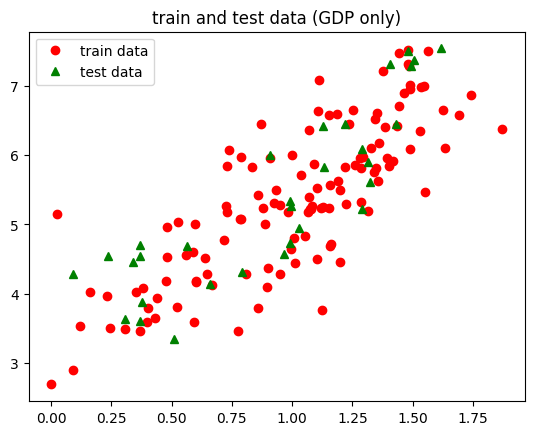

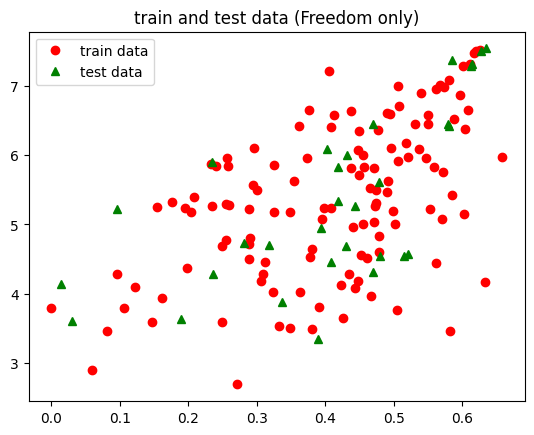

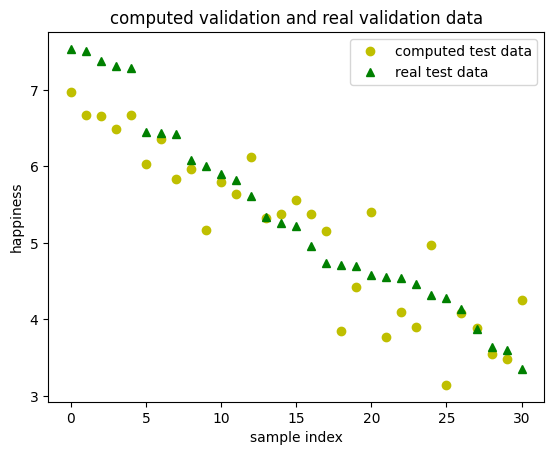

mse (manual): 0.315610522012487
mse (tool): 0.3156105220124869
R^2 score (manual): 0.7880340195072572
R^2 score: 0.788034019507257


In [108]:
class MyLinearBivariateRegression:
    def __init__(self, learning_rate=0.0001, iterations=1000):
        self.lr = learning_rate
        self.epochs = iterations
        self.w0 = 0.0
        self.w1 = 0.0 
        self.w2 = 0.0

    def fit(self, X, y):
        n = len(y)
        
        for _ in range(self.epochs):
            for i in range(n):
                x1 = X[i][0]
                x2 = X[i][1]
                target = y[i]
                
                prediction = self.w0 + (self.w1 * x1) + (self.w2 * x2)
                
                error = prediction - target
                
                self.w0 -= self.lr * error
                self.w1 -= self.lr * error * x1
                self.w2 -= self.lr * error * x2

    def predict(self, X):
        return [self.w0 + (self.w1 * row[0]) + (self.w2 * row[1]) for row in X]
    
# GDP + Freedom (v1) custom
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs_gdp, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
inputs_freedom, _ = loadData(filePath, 'Freedom', 'Happiness.Score')

plotDataHistogram(inputs_gdp, 'GDP')
plotDataHistogram(inputs_freedom, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

plotData(inputs_gdp, outputs, [], [], [], [], 'GDP vs. happiness')
plotData(inputs_freedom, outputs, [], [], [], [], 'Freedom vs. happiness')

X = [[gdp, freedom] for gdp, freedom in zip(inputs_gdp, inputs_freedom)]

np.random.seed(5)
indexes = [i for i in range(len(X))]
trainSample = np.random.choice(indexes, int(0.8 * len(X)), replace=False)
validationSample = [i for i in indexes if not i in trainSample]

trainInputs = [X[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = [X[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

train_gdp = [inputs_gdp[i] for i in trainSample]
validation_gdp = [inputs_gdp[i] for i in validationSample]
plotData(train_gdp, trainOutputs, [], [], validation_gdp, validationOutputs, "train and test data (GDP only)")

train_freedom = [inputs_freedom[i] for i in trainSample]
validation_freedom = [inputs_freedom[i] for i in validationSample]
plotData(train_freedom, trainOutputs, [], [], validation_freedom, validationOutputs, "train and test data (Freedom only)")

regressor = MyLinearBivariateRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.w0, regressor.w1, regressor.w2

computedValidationOutputs = regressor.predict(validationInputs)

plt.plot(range(len(validationOutputs)), computedValidationOutputs, 'yo', label='computed test data')
plt.plot(range(len(validationOutputs)), validationOutputs, 'g^', label='real test data')
plt.title('computed validation and real validation data')
plt.xlabel('sample index')
plt.ylabel('happiness')
plt.legend()
plt.show()

error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print("mse (manual):", error)

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print("mse (tool):", error)

y_true = validationOutputs
y_pred = computedValidationOutputs
y_mean = sum(y_true) / len(y_true)
ss_res = sum((yt - yp) ** 2 for yt, yp in zip(y_true, y_pred))
ss_tot = sum((yt - y_mean) ** 2 for yt in y_true)
r2_manual = 1 - ss_res / ss_tot
print("R^2 score (manual):", r2_manual)

r2 = r2_score(validationOutputs, computedValidationOutputs)
print("R^2 score:", r2)